DataSet preparation

In [44]:
import pandas as pd

data = pd.read_csv('StudentsPerformance.csv')


In [93]:
# check for null values
print(data.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [56]:
# One hot encoding -> convert strings to categorical data
df = pd.DataFrame(data, columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'])
encoded_data = pd.get_dummies(df, columns = ['gender', 'race/ethnicity', 'parental level of education', 'lunch','test preparation course' ])
print(encoded_data)

     gender_female  gender_male  race/ethnicity_group A  \
0             True        False                   False   
1             True        False                   False   
2             True        False                   False   
3            False         True                    True   
4            False         True                   False   
..             ...          ...                     ...   
995           True        False                   False   
996          False         True                   False   
997           True        False                   False   
998           True        False                   False   
999           True        False                   False   

     race/ethnicity_group B  race/ethnicity_group C  race/ethnicity_group D  \
0                      True                   False                   False   
1                     False                    True                   False   
2                      True                   False   

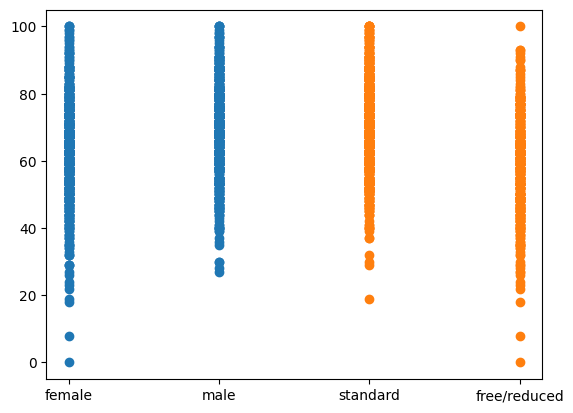

In [69]:
X = df[['gender', 'race/ethnicity','parental level of education', 'lunch', 'test preparation course']]
y = data['math score']

plt.scatter(X['gender'], y)
plt.scatter(X['lunch'], y)
plt.show()


In [58]:
# Train-Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(encoded_data, y, test_size=0.2, random_state=42)

In [94]:
#Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x_train, y_train)

# Prediction
# prediction = model.predict(x_test)
# print(prediction)


In [64]:
# Evaluating the model
from sklearn.metrics import r2_score, mean_squared_error

mse = mean_squared_error(y_test, prediction)
print(f"Mse : {mse}")
#lower mse means -> better predictions

r2 = r2_score(y_test, prediction)
print(f"R_score : {r2}")
# higher values measn better predictions

Mse : 200.51084564367295
R_score : 0.175999983382512


In [92]:
# Feature scaling 
from sklearn.preprocessing import StandardScaler

model = StandardScaler()
x_train_scaled= model.fit_transform(x_train) # this will give x_train in a scaled manner
x_test_scaled = model.transform(x_test)

# Regularization
from sklearn.linear_model import Lasso, Ridge

# L2 Regularization
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(x_train_scaled, y_train)

prediction = lasso_model.predict(x_test)
print(prediction)

mse = mean_squared_error(y_test, prediction)
print(f"Mse : {mse}")

print(lasso_model.coef_)

# L2 Regularization
ridge_model = Ridge(alpha = 1.8)
ridge_model.fit(x_train_scaled, y_train)


[64.34944141 61.5566661  68.66965623 61.11245921 72.10508575 62.32688728
 63.70347469 65.96185617 61.11245921 68.10866476 59.49963626 68.41931286
 60.03664766 60.1800787  70.41785024 67.29244094 66.19065962 63.28586545
 64.58526877 60.1800787  66.68392232 62.63180096 61.6728228  57.44563218
 64.05545874 67.71067807 71.3768284  64.34944141 60.05999985 60.1800787
 66.3800933  70.41785024 61.95528068 69.39791358 69.39791358 58.84949393
 62.32688728 65.56386948 64.53711373 57.98704992 69.20342217 68.10866476
 71.3768284  64.25663691 62.32688728 68.43825872 60.80686884 62.82942297
 69.43924953 65.44379063 69.08726547 65.56386948 69.20342217 61.5566661
 63.3708407  65.56386948 68.66965623 66.49625    66.3800933  65.98520837
 68.13201695 60.69422209 64.34944141 58.84949393 65.22173177 62.63180096
 60.1800787  59.59244077 62.88725087 65.56386948 72.10508575 65.30841958
 61.11245921 58.87284612 68.22482146 71.12648503 68.27104166 60.99630251
 63.27803619 65.51764929 62.32688728 61.34828657 67.4

C:\Program Files\Python311\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


Ridge(alpha=1.8)